<h1 style="text-align:center;color:white;background-color:#2471A3;padding:10px;border-radius:8px;">Indian Import Trend Analysis</h1>

### Introduction to indian import trend analysis
India imports a wide range of commodities from different countries through multiple ports and states. Analyzing import trends helps understand trade patterns, economic activity, commodity demand, logistics efficiency, and country-wise dependencies.Understanding import patterns manually is difficult due to the large volume of data.

This project focuses on analyzing Indian import data using Python-based data analytics and visualization techniques. The project aims to discover hidden trends, identify high-value commodities, analyze importing states and ports, and build meaningful visualizations for decision-making.


### Data Source
The dataset used in this project was collected through Google Dataset Search,which directed me to the original dataset hosted on India Data Port(https://indiadataportal.com/).
***Note:-*** The original file name was "imports at principal commodity level",but I renamed it to "indian import trend analysis".

## Problem Statement

India imports a large variety of products and commodities from different countries to meet consumer and industrial demand. However, due to the vast volume of import data, it is difficult to identify market trends, high-demand commodities, key trading partners, and regional import patterns through traditional methods.

Businesses and marketers require data-driven insights to understand market demand, supply chain dependencies, and emerging opportunities. Therefore, there is a need to analyze Indian import data using data analytics and visualization techniques to uncover trends, identify major commodities and trading partners, and support strategic business and marketing decisions.

## Attribute Information

| Attribute Name | Description |
|----------------|-------------|
| id  | Unique identifier for each import transaction |
| date  | Date on which the import transaction occurred |
| state_name  | Name of the Indian state associated with the import |
| state_code  | State code corresponding to the state |
| country  | Country from which the commodity was imported |
| port  | Port through which the commodity entered India |
| pc_code  | Principal commodity code used for commodity classification |
| commodity  | Name of the imported commodity |
| units  | Unit of measurement used for quantity |
| quantity  | Quantity of commodity imported |
| dollars_value  | Import value in US Dollars |
| inr_value  | Import value in Indian Rupees |

## Technologies Used

| Technology | Purpose |
|------------|---------|
| Python | Core programming language used for data analysis |
| Pandas | Data loading, cleaning, manipulation, and preprocessing |
| NumPy | Numerical computations and array operations |
| Matplotlib | Data visualization and chart creation |
| Seaborn | Statistical data visualization and advanced plots |
| CSV Dataset | Source of Indian import trade data |

### Imported Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h2 style="
    text-align:center;
    background-color:#eef3ff;
    padding:10px 15px;
    border-radius:5px;
    color:#2c7be5;
    font-size:30px
">
 Data Loading and Initial Overview
</h2>

This step focuses on importing the dataset and understanding its basic structure before starting the preprocessing phase.

### Dataset Loading for Further Analysis

In [2]:
df = pd.read_csv("imports-at-principal-commodity-level.csv")

***Info:-*** Used Pandas to load the dataset into Python,so that it can be viewed,explored,and prepared for further analysis.

### Overview of the Dataset

In [3]:
#Displaying the Dimensions of the Dataset
print("Number of Rows:",df.shape[0])
print("Number of Columns:",df.shape[1])

Number of Rows: 1048575
Number of Columns: 17


***Info:-*** Shows how many rows and columns are present.

In [4]:
#Displaying the First 5 Rows
df.head()

,id,date,state_name,state_code,country,port,pc_code,commodity,units,quantity,dollars_value,inr_value,year,month,commodity_category,month_num,month_name
0,0,2018-01-01,Andhra Pradesh,28,Argentina,Ap Industrial Infra Ltd Ph,I7,Residul Chemicl And Alled Prod,Unknown,0,866971,5.517134e+07,2018,January,Chemicals,1,January
1,1,2018-01-01,Andhra Pradesh,28,Australia,Appiic Multi Prod Sez Vizag Dc,F2,Bulk Minerals And Ores,Unknown,0,494931,3.149586e+07,2018,January,Metals & Minerals,1,January
2,2,2018-01-01,Andhra Pradesh,28,Australia,Gangavaram Port,F1,"Coal,Coke And Briquittes Etc",Ton,639070,127186235,8.093738e+09,2018,January,Energy & Fuels,1,January
3,3,2018-01-01,Andhra Pradesh,28,Australia,Gangavaram Port,F4,Processed Minerals,Kgs,25000000,12526128,7.971240e+08,2018,January,Metals & Minerals,1,January
4,4,2018-01-01,Andhra Pradesh,28,Australia,Icd Thimmapur (Cmtl)/Ap,J9,"Paper, Paper Board And Product",Unknown,0,72837,4.635099e+06,2018,January,Paper & Wood,1,January


***info:-*** Displays the first five rows of the dataset,providing a quick preview of the data format,column structure,and sample values.

In [5]:
#Checking DataFrame Structural Summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 17 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1048575 non-null  int64  
 1   date                1048575 non-null  str    
 2   state_name          1048575 non-null  str    
 3   state_code          1048575 non-null  int64  
 4   country             1048575 non-null  str    
 5   port                1048575 non-null  str    
 6   pc_code             1048575 non-null  str    
 7   commodity           1048575 non-null  str    
 8   units               1048575 non-null  str    
 9   quantity            1048575 non-null  int64  
 10  dollars_value       1048575 non-null  int64  
 11  inr_value           1048575 non-null  float64
 12  year                1048575 non-null  int64  
 13  month               1048575 non-null  str    
 14  commodity_category  1048575 non-null  str    
 15  month_num           104857

***Info:-*** Quickly inspect the structure, data types, and missing values in a DataFrame.

In [6]:
#Displaying Statistical Summary
df.describe()

,id,state_code,quantity,dollars_value,inr_value,year,month_num
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1048575.0
mean,5.242870e+05,2.351444e+01,1.391356e+05,1.089053e+06,8.128814e+07,2.020775e+03,1.0
std,3.026977e+05,1.036397e+01,5.239664e+06,1.217982e+07,9.241067e+08,1.981281e+00,0.0
min,0.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.018000e+03,1.0
25%,2.621435e+05,1.900000e+01,0.000000e+00,5.245000e+03,3.855060e+05,2.019000e+03,1.0
50%,5.242870e+05,2.700000e+01,0.000000e+00,3.726100e+04,2.740659e+06,2.021000e+03,1.0
75%,7.864305e+05,3.200000e+01,2.100000e+01,1.931680e+05,1.425843e+07,2.022000e+03,1.0
max,1.048574e+06,9.900000e+01,4.240480e+09,2.315952e+09,1.685850e+11,2.024000e+03,1.0


***Info:-*** Provides summary statistics for numerical features including mean,median,standard deviation,minimum and maximum values.

<h2 style="
    text-align:center;
    background-color:#eef3ff;
    padding:10px 15px;
    border-radius:5px;
    color:#2c7be5;
    font-size:30px
">
 Data Preprocessing
</h2>

This step ensures the dataset is clean,consistent,and suitable for analysis.(i)**Checking and handling missing values**,(ii)**Identified and removed duplicate records**,(iii)**Convert the date column into datetime format**,(iv)**Extracted year features from the date column**,(v)**Verified numerical columns such as quantity, dollars_value and inr_value**,(vi)**Created commodity categories for sector-wise analysis**,(vii)**Prepared the cleaned dataset for exploratory data analysis and visualization**. 

### (i) Checking and handling missing values

In [7]:
#Checking Missing Values
df.isnull().sum()

id                    0
date                  0
state_name            0
state_code            0
country               0
port                  0
pc_code               0
commodity             0
units                 0
quantity              0
dollars_value         0
inr_value             0
year                  0
month                 0
commodity_category    0
month_num             0
month_name            0
dtype: int64

***Info:-*** Used to find how many missing values are present in each column.

In [8]:
#Handling missing values
df["units"] = df["units"].fillna("Unknown")
df.isnull().sum()

id                    0
date                  0
state_name            0
state_code            0
country               0
port                  0
pc_code               0
commodity             0
units                 0
quantity              0
dollars_value         0
inr_value             0
year                  0
month                 0
commodity_category    0
month_num             0
month_name            0
dtype: int64

***Info:-*** The 'units' column contained missing values. Since this attribute is categorical and the missing values were relatively few,they were replaced with ***"Unknown"*** to maintain data completeness and avoid the loss of valuable import records during analysis.

### (ii)Identified and removed duplicate records

In [9]:
#Checking the number of duplicate rows
print("Duplicate Rows Found:",df.duplicated().sum())

Duplicate Rows Found: 0


In [10]:
#Removing duplicates
print("Number of Duplicate Rows:",df.drop_duplicates(inplace=True))

Number of Duplicate Rows: None


**info :-** The dataset was checked for duplicate entries using df.duplicated().sum().The result returned 0 duplicates,indicating that no repeated rows were found.The drop_duplicates() function was applied as a standard preprocessing step,although no removal was required.

### (iii)Convert the date column into datetime format

In [11]:
# Converting the datatype of date column
df['date'] = pd.to_datetime(df['date'])

In [12]:
#After changing the datatype
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 17 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1048575 non-null  int64         
 1   date                1048575 non-null  datetime64[us]
 2   state_name          1048575 non-null  str           
 3   state_code          1048575 non-null  int64         
 4   country             1048575 non-null  str           
 5   port                1048575 non-null  str           
 6   pc_code             1048575 non-null  str           
 7   commodity           1048575 non-null  str           
 8   units               1048575 non-null  str           
 9   quantity            1048575 non-null  int64         
 10  dollars_value       1048575 non-null  int64         
 11  inr_value           1048575 non-null  float64       
 12  year                1048575 non-null  int64         
 13  month               104

**Info :-** The 'date' column was converted from **'string'** format to **'datetime'** format using pandas. This conversion enables efficient date-based operations, such as extracting year and month information, performing trend analysis, and creating time-series visualizations. 

### (iv)Extracted year feature from the date column

In [13]:
df.drop(columns=['month','month_name'],inplace=True)

In [44]:
df.drop(columns=['month_num'],inplace=True)

In [45]:
df['year']= df['date'].dt.year
df.head()

,id,date,state_name,state_code,country,port,pc_code,commodity,units,quantity,dollars_value,inr_value,year,commodity_category
0,0,2018-01-01,Andhra Pradesh,28,Argentina,Ap Industrial Infra Ltd Ph,I7,Residul Chemicl And Alled Prod,Unknown,0,866971,"55,171,345.00",2018,Chemicals
1,1,2018-01-01,Andhra Pradesh,28,Australia,Appiic Multi Prod Sez Vizag Dc,F2,Bulk Minerals And Ores,Unknown,0,494931,"31,495,862.00",2018,Metals & Minerals
2,2,2018-01-01,Andhra Pradesh,28,Australia,Gangavaram Port,F1,"Coal,Coke And Briquittes Etc",Ton,639070,127186235,"8,093,737,688.00",2018,Energy & Fuels
3,3,2018-01-01,Andhra Pradesh,28,Australia,Gangavaram Port,F4,Processed Minerals,Kgs,25000000,12526128,"797,123,968.00",2018,Metals & Minerals
4,4,2018-01-01,Andhra Pradesh,28,Australia,Icd Thimmapur (Cmtl)/Ap,J9,"Paper, Paper Board And Product",Unknown,0,72837,"4,635,099.00",2018,Paper & Wood


**info:-** The year and month columns were extracted from the date attribute to facilitate time-based analysis.These derived features help identify yearly growth patterns, monthly trends, and seasonal variations in india's import activities

### (v)Verified numerical columns such as quantity, dollars_value and inr_value

In [15]:
#Check numerical values
df[['quantity','dollars_value','inr_value']].describe()

,quantity,dollars_value,inr_value
count,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.391356e+05,1.089053e+06,8.128814e+07
std,5.239664e+06,1.217982e+07,9.241067e+08
min,0.000000e+00,0.000000e+00,1.000000e+00
25%,0.000000e+00,5.245000e+03,3.855060e+05
50%,0.000000e+00,3.726100e+04,2.740659e+06
75%,2.100000e+01,1.931680e+05,1.425843e+07
max,4.240480e+09,2.315952e+09,1.685850e+11


**info :-** Numerical attributes were analyzed using summary statistics to understand their range, average values, and distribution.

### (vi)Create new commodity category column

In [16]:
commodity_category = {

# Energy & Fuels
'Coal,Coke And Briquittes Etc':'Energy & Fuels',
'Petroleum Products':'Energy & Fuels',
'Petroleum: Crude':'Energy & Fuels',

# Metals & Minerals
'Bulk Minerals And Ores':'Metals & Minerals',
'Processed Minerals':'Metals & Minerals',
'Other Crude Minerals':'Metals & Minerals',
'Iron Ore':'Metals & Minerals',
'Iron And Steel':'Metals & Minerals',
'Products Of Iron And Steel':'Metals & Minerals',
'Aluminium, Products Of Aluminm':'Metals & Minerals',
'Copper And Prdcts Made Of Copr':'Metals & Minerals',
'Lead And Products Made Of Led':'Metals & Minerals',
'Nickel, Product Made Of Nickel':'Metals & Minerals',
'Tin And Products Made Of Tin':'Metals & Minerals',
'Zinc And Products Made Of Zinc':'Metals & Minerals',
'Gold':'Metals & Minerals',
'Silver':'Metals & Minerals',
'Other Precious And Base Metals':'Metals & Minerals',
'Oth Non Ferous Metal And Prodc':'Metals & Minerals',

# Chemicals
'Residul Chemicl And Alled Prod':'Chemicals',
'Organic Chemicals':'Chemicals',
'Inorganic Chemicals':'Chemicals',
'Other Miscellaenious Chemicals':'Chemicals',
'Agro Chemicals':'Chemicals',
'Dyes':'Chemicals',
'Dye Intermediates':'Chemicals',
'Essential Oils':'Chemicals',
'Paint, Varnish And Allid Prodc':'Chemicals',
'Cashew Nut Shell Liquid':'Chemicals',
'Graphite, Explsivs And Accesor':'Chemicals',
'Sulpher, Unroasted Iron Pyrite':'Chemicals',

# Fertilizers
'Fertilezers Crude':'Fertilizers',
'Fertilezers Manufactured':'Fertilizers',

# Pharmaceuticals & Medical
'Bulk Drugs, Drug Intermediates':'Pharmaceuticals',
'Drug Formulations, Biologicals':'Pharmaceuticals',
'Surgicals':'Pharmaceuticals',
'Medical And Scientific Instrum':'Pharmaceuticals',
'Ayush And Herbal Products':'Pharmaceuticals',

# Machinery & Engineering
'Ac, Refrigeration Machnry Etc':'Machinery',
'Atm, Injctng Mlding Mchnry Etc':'Machinery',
'Cranes, Lifts And Winches':'Machinery',
'Machine Tools':'Machinery',
'Pumps Of All Types':'Machinery',
'Nucler Reactr, Indl Boilr, Prt':'Machinery',
'Project Goods':'Machinery',
'Other Construction Machinery':'Machinery',
'Indl. Machnry For Dairy Etc':'Machinery',
'Hnd Tool, Cttng Tool Of Metals':'Machinery',
'Ic Engines And Parts':'Machinery',
'Other Misc. Engineering Items':'Machinery',

# Electronics & Electrical
'Computer Hardware, Peripherals':'Electronics',
'Consumer Electronics':'Electronics',
'Electronics Components':'Electronics',
'Electronics Instruments':'Electronics',
'Telecom Instruments':'Electronics',
'Electric Machinery And Equipme':'Electronics',
'Accumulators And Batteries':'Electronics',
'Office Equipments':'Electronics',
'Optical Items (Incl.Lens Etc)':'Electronics',
'Electrodes':'Electronics',

# Transport Equipment
'Aircraft, Spacecraft And Parts':'Transport',
'Auto Components/Parts':'Transport',
'Motor Vehicle/Cars':'Transport',
'Two And Three Wheelers':'Transport',
'Railwy Trnsprt Equipmnts, Prts':'Transport',
'Ship, Boat And Floating Struct':'Transport',
'Bicycle And Parts':'Transport',
'Auto Tyres And Tubes':'Transport',

# Plastics & Rubber
'Plastic Raw Materials':'Plastics & Rubber',
'Other Plastic Items':'Plastics & Rubber',
'Plastc Sht, Film, Plts Etc':'Plastics & Rubber',
'Moulded And Extruded Goods':'Plastics & Rubber',
'Natural Rubber':'Plastics & Rubber',
'Othr Rubber Prodct Excpt Footw':'Plastics & Rubber',

# Paper, Wood & Packaging
'Paper, Paper Board And Product':'Paper & Wood',
'Newsprint':'Paper & Wood',
'Pulp And Waste Paper':'Paper & Wood',
'Other Wood And Wood Products':'Paper & Wood',
'Plywood And Allied Products':'Paper & Wood',
'Packaging Materials':'Paper & Wood',

# Agriculture & Food
'Pulses':'Agriculture & Food',
'Rice(Other Than Basmoti)':'Agriculture & Food',
'Wheat':'Agriculture & Food',
'Other Cereals':'Agriculture & Food',
'Sugar':'Agriculture & Food',
'Coffee':'Agriculture & Food',
'Tea':'Agriculture & Food',
'Spices':'Agriculture & Food',
'Cashew':'Agriculture & Food',
'Fresh Fruits':'Agriculture & Food',
'Fresh Vegetables':'Agriculture & Food',
'Processed Fruits And Juices':'Agriculture & Food',
'Processed Vegetables':'Agriculture & Food',
'Cereal Preparations':'Agriculture & Food',
'Dairy Products':'Agriculture & Food',
'Cocoa Products':'Agriculture & Food',

# Oils & Seeds
'Vegetable Oils':'Oils & Seeds',
'Oil Meals':'Oils & Seeds',
'Groundnut':'Oils & Seeds',
'Sesame Seeds':'Oils & Seeds',
'Niger Seeds':'Oils & Seeds',
'Other Oil Seeds':'Oils & Seeds',
'Castor Oil':'Oils & Seeds',
'Fruits / Vegetable Seeds':'Oils & Seeds',

# Animal Products
'Marine Products':'Animal Products',
'Poultry Products':'Animal Products',
'Other Meat':'Animal Products',
'Processed Meat':'Animal Products',
'Sheep/Goat Meat':'Animal Products',
'Animal Casings':'Animal Products',

# Textiles & Apparel
'Cotton Yarn':'Textiles',
'Cotton Fabrics, Madeups Etc.':'Textiles',
'Cotton Raw Incld. Waste':'Textiles',
'Rmg Cotton Incl Accessories':'Textiles',
'Rmg Manmade Fibres':'Textiles',
'Rmg Silk':'Textiles',
'Rmg Wool':'Textiles',
'Rmg Of Othr Textle Matrl':'Textiles',
'Manmade Yarn,Fabrics,Madeups':'Textiles',
'Manmade Staple Fibre':'Textiles',
'Natrl Silk Yarn,Fabrics,Madeup':'Textiles',
'Silk,Raw':'Textiles',
'Silk Waste':'Textiles',
'Wollen Yarn,Fabrics,Madeupsetc':'Textiles',
'Wool, Raw':'Textiles',
'Oth Txtl Yrn, Fbric Mdup Artcl':'Textiles',
'Handloom Products':'Textiles',
'Jute, Raw':'Textiles',
'Jute Yarn':'Textiles',
'Jute Hessian':'Textiles',
'Other Jute Manufactures':'Textiles',
'Floor Cvrng Of Jute':'Textiles',
'Coir And Coir Manufactures':'Textiles',

# Leather & Footwear
'Finished Leather':'Leather',
'Leather Goods':'Leather',
'Leather Garments':'Leather',
'Leather Footwear Component':'Leather',
'Footwear Of Leather':'Leather',
'Footwear Of Rubber/Canvas Etc.':'Leather',
'Raw Hides And Skins':'Leather',
'Saddlery And Harness':'Leather',

# Gems & Jewellery
'Pearl, Precs, Semiprecs Stones':'Gems & Jewellery',
'Gold And Oth Precs Metl Jwlery':'Gems & Jewellery',

# Construction Materials
'Cmnt, Clinkr And Asbstos Cmnt':'Construction Materials',
'Ceramics And Allied Products':'Construction Materials',
'Glass And Glassware':'Construction Materials',
'Granit, Natrl Stone And Prodct':'Construction Materials',
'Mica':'Construction Materials',
'Prime Mica And Mica Products':'Construction Materials',

# Consumer & Miscellaneous
'Books, Publications And Prntng':'Consumer Goods',
'Cosmetics And Toiletries':'Consumer Goods',
'Sports Goods':'Consumer Goods',
'Stationry/Offce, School Supply':'Consumer Goods',
'Tobacco Manufactured':'Consumer Goods',
'Tobacco Unmanufactured':'Consumer Goods',
'Alcoholic Beverages':'Consumer Goods',
'Floricltr Products':'Consumer Goods',
'Handcrfs(Excl.Handmade Crpts)':'Consumer Goods',
'Carpet(Excl. Silk) Handmade':'Consumer Goods',
'Silk Carpet':'Consumer Goods',
'Human Hair, Products Thereo':'Consumer Goods',
'Guergam Meal':'Consumer Goods',
'Misc Processed Items':'Consumer Goods',
'Milled Products':'Consumer Goods',
'Mollases':'Consumer Goods',
'Shellac':'Consumer Goods',
'Other Commodities':'Consumer Goods'
}

df['commodity_category'] = df['commodity'].map(commodity_category)



In [17]:
df.head()

,id,date,state_name,state_code,country,port,pc_code,commodity,units,quantity,dollars_value,inr_value,year,commodity_category,month_num
0,0,2018-01-01,Andhra Pradesh,28,Argentina,Ap Industrial Infra Ltd Ph,I7,Residul Chemicl And Alled Prod,Unknown,0,866971,5.517134e+07,2018,Chemicals,1
1,1,2018-01-01,Andhra Pradesh,28,Australia,Appiic Multi Prod Sez Vizag Dc,F2,Bulk Minerals And Ores,Unknown,0,494931,3.149586e+07,2018,Metals & Minerals,1
2,2,2018-01-01,Andhra Pradesh,28,Australia,Gangavaram Port,F1,"Coal,Coke And Briquittes Etc",Ton,639070,127186235,8.093738e+09,2018,Energy & Fuels,1
3,3,2018-01-01,Andhra Pradesh,28,Australia,Gangavaram Port,F4,Processed Minerals,Kgs,25000000,12526128,7.971240e+08,2018,Metals & Minerals,1
4,4,2018-01-01,Andhra Pradesh,28,Australia,Icd Thimmapur (Cmtl)/Ap,J9,"Paper, Paper Board And Product",Unknown,0,72837,4.635099e+06,2018,Paper & Wood,1


**Info :-** A new column amed commodity_category was created into broader business sectors such as Electronics & Technology, Metals & Minerals, Chemicals & Pharma, Agriculture & food , and Machinery & Equipment. this Categorization simplifies analysis and helps identify sector-wise import trends.

In [18]:
# saved the commodity_categorical column permanently in the dataset
df.to_csv('imports-at-principal-commodity-level.csv', index=False)

**Info :-** **Commodity_category** column the processed dataset was saved as a new file to permanently retain the changes for future analysis and reporting.

<h2 style="
    text-align:center;
    background-color:#eef3ff;
    padding:10px 15px;
    border-radius:5px;
    color:#2c7be5;
    font-size:30px
">
 Exploratory Data Analysis (EDA)
</h2>

**Exploratory Data analysis** is the process of examining and summarizing data to understand its structure, identify patterns, detect anomalies, and discover relationship between variables. In this project, EDA was performed using statistical summaries, grouping techniques, pivot tables, and visualization to gain meaningful insights into india's import trends across commodities, countries, states, and time periods.

#### (i) Univariate Analysis
Analyze individual variables to understand their distribution and characteristics.


In [19]:
df.columns

Index(['id', 'date', 'state_name', 'state_code', 'country', 'port', 'pc_code',
       'commodity', 'units', 'quantity', 'dollars_value', 'inr_value', 'year',
       'commodity_category', 'month_num'],
      dtype='str')

In [20]:
# to display normal numbers instead of scientific notaion
pd.options.display.float_format = '{:,.2f}'.format

In [21]:
# numerical variables
df[['quantity','dollars_value','inr_value']].describe()

,quantity,dollars_value,inr_value
count,"1,048,575.00","1,048,575.00","1,048,575.00"
mean,"139,135.64","1,089,053.13","81,288,137.29"
std,"5,239,664.07","12,179,819.49","924,106,669.26"
min,0.00,0.00,1.00
25%,0.00,"5,245.00","385,506.00"
50%,0.00,"37,261.00","2,740,659.00"
75%,21.00,"193,168.00","14,258,427.50"
max,"4,240,479,619.00","2,315,951,886.00","168,585,000,000.00"


**Info:-** Descriptive statistics were generated for quantity, USD value, and INR value to understand the centeral tendency, spread minimum and maximum values, and overall distribution of import transactions. 

In [22]:
# Categorical variables
df['commodity_category'].value_counts()

commodity_category
Machinery                 158758
Metals & Minerals         153683
Electronics               139975
Plastics & Rubber         104239
Chemicals                  92507
Consumer Goods             84568
Paper & Wood               64989
Textiles                   60872
Pharmaceuticals            44979
Construction Materials     36548
Transport                  31870
Agriculture & Food         24466
Leather                    17757
Energy & Fuels             14493
Gems & Jewellery            7792
Oils & Seeds                5399
Fertilizers                 3448
Animal Products             2232
Name: count, dtype: int64

In [23]:
df['country'].value_counts().head(10)

country
China P Rp     103264
U S A           67100
Germany         55412
Singapore       42425
Japan           41560
Italy           36455
U K             36304
Korea Rp        34565
Thailand        32505
U Arab Emts     31462
Name: count, dtype: int64

In [24]:
df['units'].value_counts()

units
Unknown    703490
Kgs        181075
Ton        153187
Nos          4901
Ltr          3061
Sqm          2861
Name: count, dtype: int64

***Info:-*** In categorical feature analysis frequency distribution were analyzed for commodity categories, countries, and units to identify the most common categories and dominant import sources.

### (ii) Bivariate Analysis

**Commodity Category vs Import Value**

In [25]:
category_import = df.groupby('commodity_category')['inr_value'].sum()
category_import.sort_values(ascending=False)

commodity_category
Energy & Fuels           27,979,677,443,602.00
Metals & Minerals        12,452,302,730,949.00
Electronics              11,609,388,879,026.00
Machinery                 5,846,843,494,929.00
Chemicals                 5,432,333,798,555.00
Gems & Jewellery          4,379,376,717,529.00
Transport                 3,338,847,157,135.00
Plastics & Rubber         3,254,142,738,434.00
Oils & Seeds              2,167,362,879,666.00
Pharmaceuticals           1,870,875,077,175.00
Consumer Goods            1,436,132,249,679.00
Paper & Wood              1,252,377,475,965.00
Agriculture & Food        1,238,486,968,988.00
Fertilizers               1,211,240,135,239.00
Textiles                  1,031,085,488,723.00
Construction Materials      523,196,358,520.00
Leather                     178,312,541,311.00
Animal Products              34,726,427,371.00
Name: inr_value, dtype: float64

**Info:-** This analysis identifies which commodity sectors contribute the highest share of india's imports.

**Country vs Import Value**

In [26]:
country_import = df.groupby('country')['inr_value'].sum().sort_values(ascending=False)
country_import.head(10)

country
China P Rp    12,197,058,972,272.00
U Arab Emts    6,021,576,029,506.00
U S A          5,771,490,444,691.00
Saudi Arab     4,635,652,408,753.00
Iraq           4,177,915,776,361.00
Russia         3,532,644,618,664.00
Switzerland    2,945,545,376,579.00
Indonesia      2,705,607,794,907.00
Korea Rp       2,643,397,574,198.00
Singapore      2,638,111,508,503.00
Name: inr_value, dtype: float64

**Info:-** Country_level analysis was performed to identify India's major import partners and their contribution to total import value.

**State vs Import Value**


In [27]:
state_import = df.groupby('state_name')['inr_value'].sum().sort_values(ascending=False)
state_import.head(10)

state_name
Gujarat          23,493,124,587,319.00
Maharashtra      18,839,290,162,331.00
Tamil Nadu       11,082,163,125,994.00
Delhi             7,386,550,394,869.00
Andhra Pradesh    6,006,590,202,554.00
Odisha            4,118,070,188,402.00
Karnataka         3,689,518,023,879.00
West Bengal       3,054,442,073,402.00
Kerala            2,288,926,127,195.00
Haryana           1,018,875,253,241.00
Name: inr_value, dtype: float64

**Info:-** The analysis highlights states contributing significantly to import activities and trade volume.

**Quantity vs INR Value**

In [28]:
df[['quantity','inr_value']].corr()

,quantity,inr_value
quantity,1.00,0.03
inr_value,0.03,1.00


**Info:-** Correlation analysis was conducted to determine whether larger import quantities are associated with higher import values.

### (iii) Multivariate Analysis

**Commodity Category + Country**

In [29]:
pivot1 = pd.pivot_table(df,
                        values='inr_value',
                        index='commodity_category',
                        columns='country',
                        aggfunc='sum')
pivot1.head()

country,Afghanistan,Albania,Algeria,Ameri Samoa,Andorra,Angola,Anguilla,Antartica,Antigua,Argentina,...,Uzbekistan,Vanuatu Rep,Vatican City,Venezuela,Vietnam Soc Rep,Virgin Is Us,Wallis F Is,Yemen Republc,Zambia,Zimbabwe
commodity_category,,,,,,,,,,,,,,,,,,,,,
Agriculture & Food,"69,963,236,227.00","17,572,506.00","959,081,924.00",NaN,NaN,"14,380.00",NaN,NaN,NaN,"7,463,422,335.00",...,"1,588,450,687.00",NaN,NaN,"28,576,301.00","39,878,887,473.00",NaN,NaN,"2,893,428.00","35,489,589.00","129,043,999.00"
Animal Products,NaN,NaN,NaN,"94,815,573.00",NaN,NaN,NaN,NaN,NaN,"58,243,912.00",...,NaN,NaN,NaN,NaN,"2,882,421,549.00","3,643,979.00",NaN,"32,228,266.00",NaN,NaN
Chemicals,"10,153,115.00","482,104.00","3,477,830,145.00",NaN,NaN,"12,675,155.00","3,335,360.00","49,035,884.00",NaN,"4,866,880,476.00",...,"63,256,237.00",NaN,NaN,"4,640,469,200.00","47,715,990,090.00","2,060,171.00",NaN,"3,593,108.00","25,467,544.00",NaN
Construction Materials,"4,636,746.00","213,612,444.00","39,833,137.00",NaN,NaN,"99,755,987.00",NaN,NaN,NaN,"4,585,107.00",...,NaN,NaN,NaN,"112,532.00","11,301,787,584.00",NaN,NaN,NaN,"9,484,993.00","4,265,866.00"
Consumer Goods,"1,626,433,018.00","3,036,608.00","9,823,020.00",NaN,NaN,"243,509,286.00",NaN,"4,940,992.00","31,875,761.00","811,520,870.00",...,"115,024,479.00",NaN,350.00,"120,424,390.00","18,559,821,157.00","419,208.00",NaN,"3,844,938,198.00","31,429,151.00","1,932,626,841.00"


**Info:-** A pivot table was created to analyze import value across commodity categories and countries simultaneously.

**Year + Commodity Category**

In [30]:
pivot2 = pd.pivot_table(df,
                        values='inr_value',
                        index='year',
                        columns='commodity_category',
                        aggfunc='sum')
pivot2.head()

commodity_category,Agriculture & Food,Animal Products,Chemicals,Construction Materials,Consumer Goods,Electronics,Energy & Fuels,Fertilizers,Gems & Jewellery,Leather,Machinery,Metals & Minerals,Oils & Seeds,Paper & Wood,Pharmaceuticals,Plastics & Rubber,Textiles,Transport
year,,,,,,,,,,,,,,,,,,
2018,"135,835,984,792.00","3,615,205,845.00","683,850,978,977.00","62,760,026,171.00","198,369,560,832.00","1,334,529,357,712.00","3,380,960,749,219.00","90,332,909,562.00","690,922,844,468.00","28,521,864,184.00","758,893,034,858.00","1,559,126,649,489.00","237,212,892,505.00","172,131,854,353.00","217,951,553,339.00","392,210,496,624.00","127,296,873,279.00","415,385,068,647.00"
2019,"139,911,672,928.00","4,553,256,370.00","743,876,065,942.00","71,375,084,517.00","209,664,485,466.00","1,463,147,075,429.00","3,698,376,116,907.00","155,321,753,533.00","634,387,634,922.00","31,770,279,872.00","863,522,095,598.00","1,785,342,755,043.00","236,321,339,544.00","199,414,133,108.00","253,835,148,383.00","424,624,346,592.00","147,538,372,532.00","455,681,458,472.00"
2020,"156,631,610,263.00","4,896,064,190.00","624,791,078,899.00","58,660,937,098.00","162,875,780,924.00","1,172,300,557,973.00","3,263,236,660,788.00","120,378,078,320.00","394,520,574,674.00","26,175,508,465.00","686,217,095,739.00","1,036,428,037,635.00","251,384,787,449.00","149,109,624,270.00","227,327,581,193.00","354,102,136,899.00","121,697,895,101.00","475,971,347,846.00"
2021,"173,648,218,748.00","5,783,901,593.00","917,762,128,829.00","83,386,207,459.00","221,855,190,920.00","1,774,211,054,612.00","3,384,144,220,832.00","102,703,864,525.00","714,936,924,423.00","24,546,172,624.00","889,868,791,824.00","2,674,331,979,142.00","331,694,869,241.00","185,890,492,194.00","297,429,152,309.00","566,543,864,218.00","171,111,671,631.00","460,210,923,219.00"
2022,"159,137,858,758.00","4,061,171,710.00","844,788,072,102.00","72,752,910,503.00","211,667,254,157.00","1,934,171,983,561.00","4,472,600,714,143.00","369,928,878,343.00","683,937,421,664.00","25,263,638,569.00","759,459,022,856.00","1,624,825,502,742.00","394,067,976,874.00","168,291,459,365.00","254,770,811,216.00","479,828,206,666.00","150,900,768,450.00","305,561,720,483.00"


**Info:-** This analysis examines how import values for different commodity categories changes over time.

**State + Commodity Category**

In [31]:
pivot3 = pd.pivot_table(df,
                        values='inr_value',
                        index='state_name',
                        columns='commodity_category',
                        aggfunc='sum')
pivot3.head()

commodity_category,Agriculture & Food,Animal Products,Chemicals,Construction Materials,Consumer Goods,Electronics,Energy & Fuels,Fertilizers,Gems & Jewellery,Leather,Machinery,Metals & Minerals,Oils & Seeds,Paper & Wood,Pharmaceuticals,Plastics & Rubber,Textiles,Transport
state_name,,,,,,,,,,,,,,,,,,
Andhra Pradesh,"39,241,578,130.00","1,746,184,339.00","317,086,498,927.00","10,044,051,885.00","26,688,145,714.00","92,834,786,280.00","2,165,006,113,227.00","322,903,127,455.00","78,918,842,196.00","5,385,777,700.00","151,608,213,608.00","1,833,189,982,163.00","354,376,954,149.00","38,491,751,571.00","58,703,034,948.00","24,510,861,336.00","21,162,715,844.00","464,691,583,082.00"
Assam,"1,020,218,408.00",NaN,"89,669,837.00","2,642,223,420.00","1,393,839,750.00","75,222,366.00","48,465,737.00",NaN,NaN,"9,285,244.00","155,749,878.00","4,627,377,316.00","1,164,828,544.00","314,202,844.00","213,815.00","1,022,145,875.00","1,936,954,027.00","5,864,990.00"
Bihar,"2,531,476,866.00",NaN,"336,941,521.00","67,078,441.00","9,919,521,990.00","308,065,889.00",NaN,NaN,NaN,"1,296,124,863.00","254,508,046.00","7,599,958,891.00","36,117,695,330.00","2,093,009,470.00","678,755,271.00","4,068,263,304.00","15,922,492,206.00","17,718,530.00"
Chandigarh,NaN,NaN,NaN,NaN,NaN,"27,779,036.00",NaN,NaN,NaN,NaN,"4,429,434.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
Chhattisgarh,"2,327,955.00",NaN,"22,890,522.00","161,212,591.00","40,775,022.00","660,496,617.00","25,931,511.00",NaN,NaN,"1,949.00","265,117,985.00","2,710,955,192.00",NaN,"176,613,991.00","27,573,422.00","52,090,122.00","189,626.00","44,642,829.00"


**Info:-** This analysis helps identify which commodity sectors dominate imports in different states.

### (iv) Correlation Analysis

In [32]:
# correlation between quantity, dollar value,inr value
corr = df[['quantity','dollars_value','inr_value']].corr()
corr

,quantity,dollars_value,inr_value
quantity,1.00,0.03,0.03
dollars_value,0.03,1.00,1.00
inr_value,0.03,1.00,1.00


**Info:-** Correlation analysis was performed on numerical variables to identify relationship between import quantity, USD values, and INR value.

<h2 style="
    text-align:center;
    background-color:#eef3ff;
    padding:10px 15px;
    border-radius:5px;
    color:#2c7be5;
    font-size:30px
">
 Data Visualizations
</h2>

Data visualization is the process of representing data using charts and grahps to better understand patterns, trends, and relationships. In this project, various visualizations are used to analyze India's import trends, identify major commodities, source countries, and import value patterns, helping to derive meaningful insights from the dataset.

### (i) Top 10 Import Commodities

• ***Visualization Type:-***  Bar Chart  
• ***Purpose:-*** Identify the most valuable import commodities.

<function matplotlib.pyplot.show(close=None, block=None)>

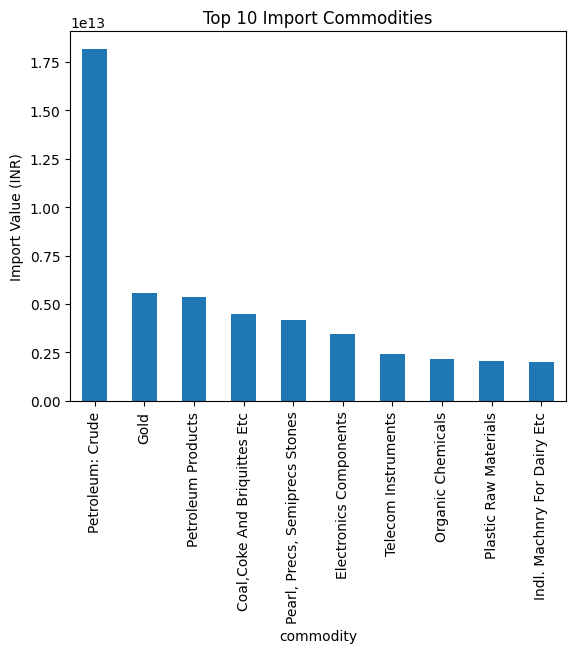

In [33]:
top_commodities = df.groupby('commodity')['inr_value'].sum().nlargest(10)

plt.Figure(figsize=(10,5))
top_commodities.plot(kind='bar')
plt.title('Top 10 Import Commodities')
plt.xlabel('commodity')
plt.ylabel('Import Value (INR)')
plt.xticks(rotation=90)
plt.show

***Insight:-*** Energy &Fuels heavily dominates national imports, costing neraly triple the amount of the next highest categories (Metals & Minerals and Electronics). beyond these top three drivers, import expenditures drop off sharply across all other sectors.

### (ii) Yearly-wise Import Trend

* ***Visualization Type:-*** Line Chart
* ***Purpose:-*** Study import growth over time.


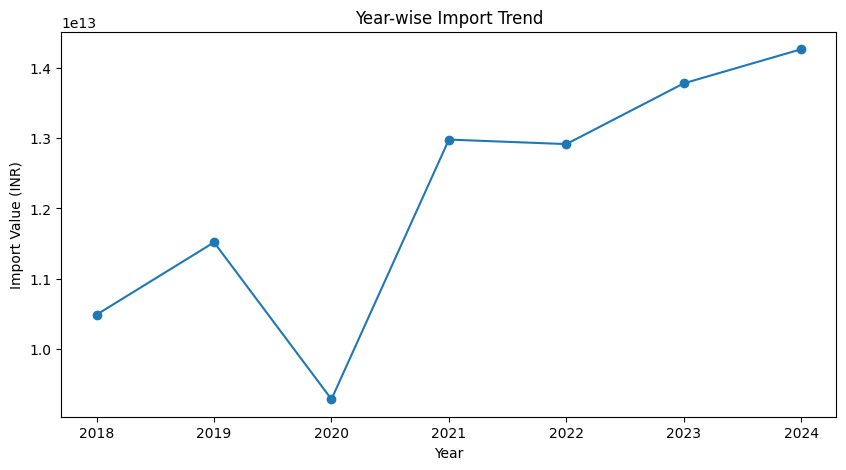

In [34]:
yearly_import = df.groupby('year')['inr_value'].sum()

plt.figure(figsize=(10,5))
yearly_import.plot(marker='o')
plt.title('Year-wise Import Trend')
plt.xlabel('Year')
plt.ylabel('Import Value (INR)')
plt.show()

***Insight:-*** Total import value shows a strong overall upward trend from 2018 to 2024, despite a sharp, temporary drop in 2020 (likely due to global pandemic trade disruptions). post 2020 imports recovered rapidly and have climbed steadily to an all-time high in 2024.

### (iii) Commodity Category share

* ***Visualization Type:-*** Pie Chart
* ***Purpose:-*** Show category contribution

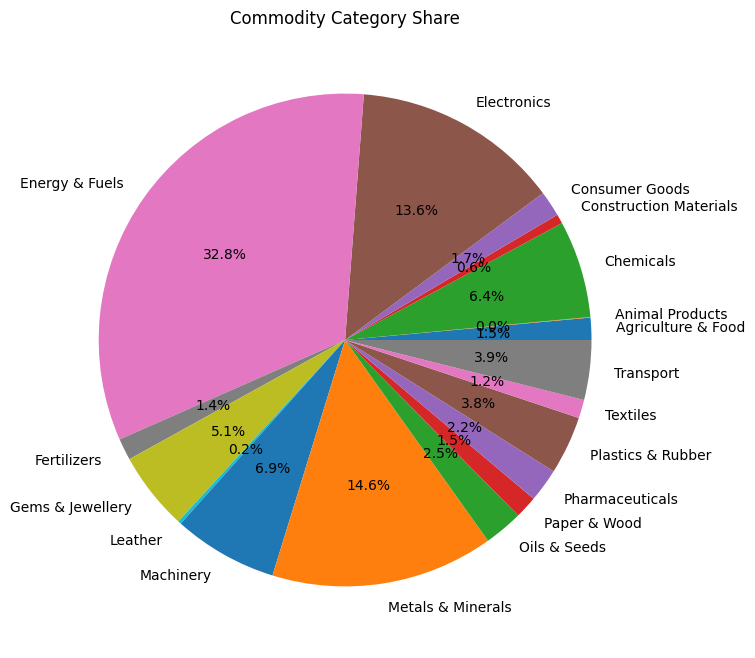

In [35]:
category_share = df.groupby(
    'commodity_category'
)['inr_value'].sum()

plt.figure(figsize=(8,8))

plt.pie(
    category_share,
    labels=category_share.index,
    autopct='%1.1f%%'
)

plt.title('Commodity Category Share')

plt.show()

***Insight:-*** **Energy & Fuels** dominates the total market share at 32.8%, closely followed by the secondary key drivers: **OILS & Seeds** (14.6%) and **Electronics(13.6%). Combined, these top three Categories account for over 60% of the entire commodity distribution, while the remaining secotrs from a highly fragmented "long tail".

### (iv) Quantity Vs Import Value

* ***visualization Type:-*** Scatter Plot
* ***Purpose:-*** Analyze Quantity-value relationship

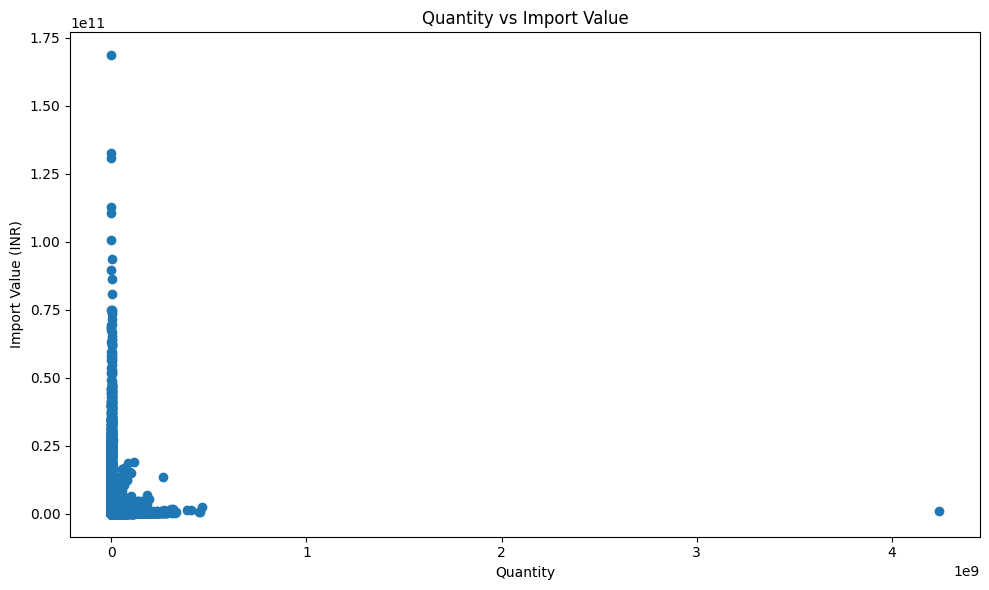

In [36]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['quantity'],
    df['inr_value']
)

plt.title('Quantity vs Import Value')
plt.xlabel('Quantity')
plt.ylabel('Import Value (INR)')

plt.tight_layout()
plt.show()

***Insight:-*** The scatter plot shows that import value does not increase linearly with quantity.instead, the data splits into two extremes:a dense vertical spike of high-value, low-quantity items (expensive priemium goods) and a extreme outlier on the far right represnting a high-volume, low-value bulk commodity.


### (v) Import Value Distribution

* ***Visualization Type:-*** Histogram
* ***Purpose:-*** Study import value distribution.


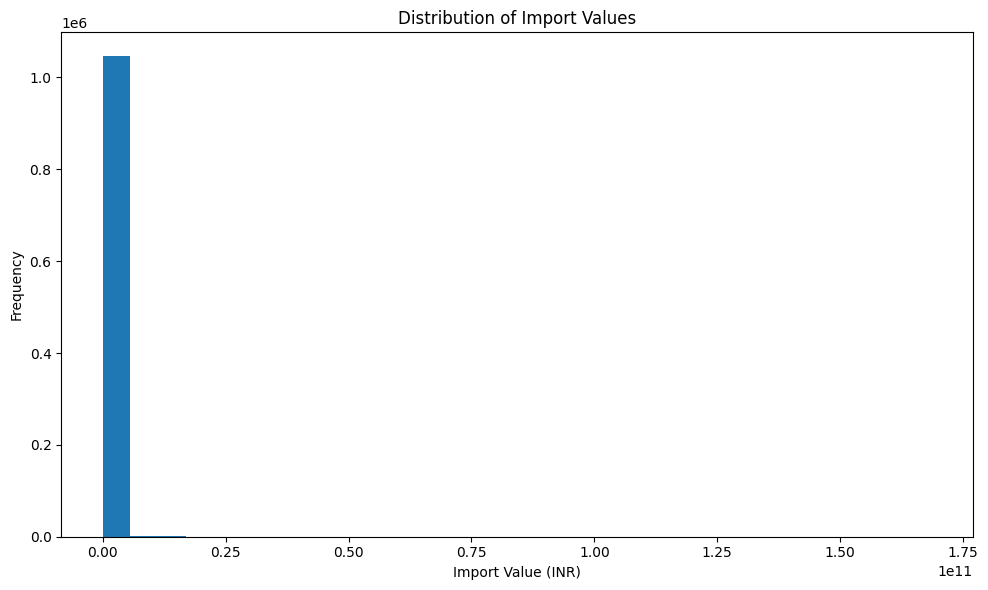

In [37]:
plt.figure(figsize=(10,6))

plt.hist(
    df['inr_value'],
    bins=30
)

plt.title('Distribution of Import Values')
plt.xlabel('Import Value (INR)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

***Insight:-*** The histogram shows an extreme right-skewed distribution. the vast majority of transaction frequencies are heavily clustered near zero, indicating that the bulk of imports consist of smaller, lower-value transactions, while a few extreme high-value transactions form a very thin, elongated tail on the right.

### (vi)Import Value by Commodity Category

* ***Visualization Type:-*** Box plot
* ***Purpose:-*** Compare import value spread among categories.

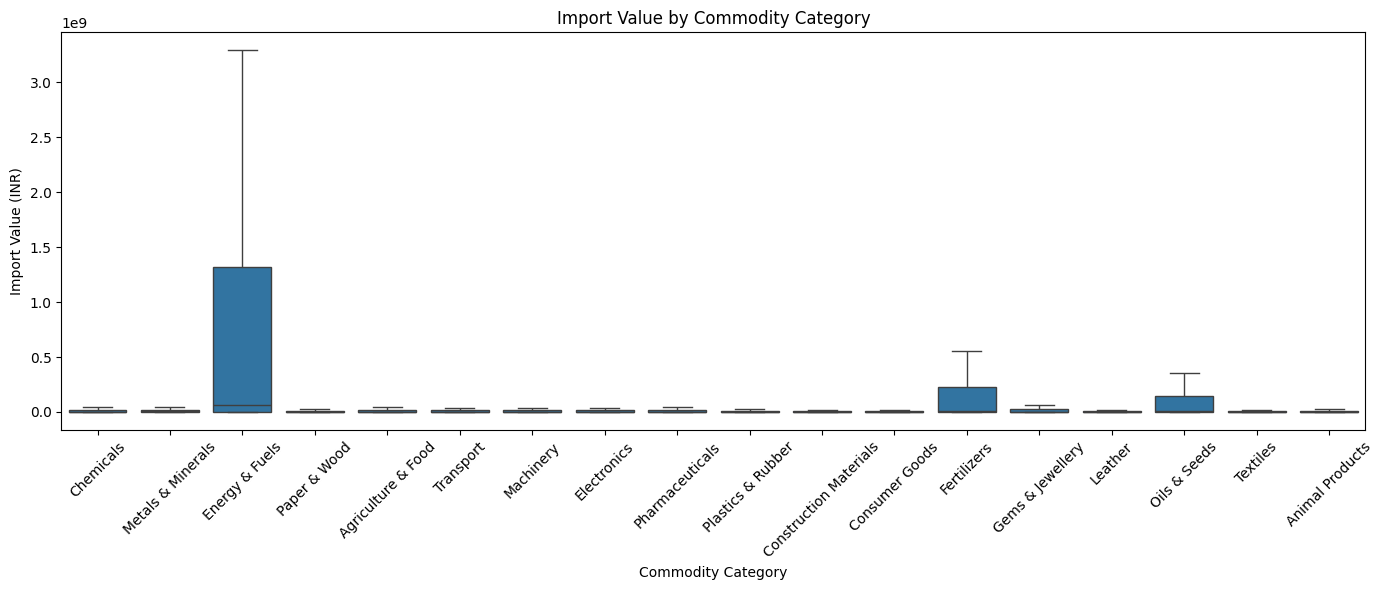

In [38]:
plt.figure(figsize=(14,6))

sns.boxplot(
    x='commodity_category',
    y='inr_value',
    data=df,
    showfliers=False
)

plt.title('Import Value by Commodity Category')
plt.xlabel('Commodity Category')
plt.ylabel('Import Value (INR)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

***Insight:-*** The box plot demonstrates that across almost all commodity categories, the vast majority of import values are tightly squeezed near zero (low median). however, categories like metala & minerals, energy & fuels, and gems & jwellery feature massive upper whiskers and an extreme outliers, proving that ttal spending is heavily skewed by a small number of incredibly expensive shipments.

### (vii) Correlation Analysis

* ***Visualization Type:-*** Heatmap
* ***Purpose:-*** Analyze correlation among numerical variables.


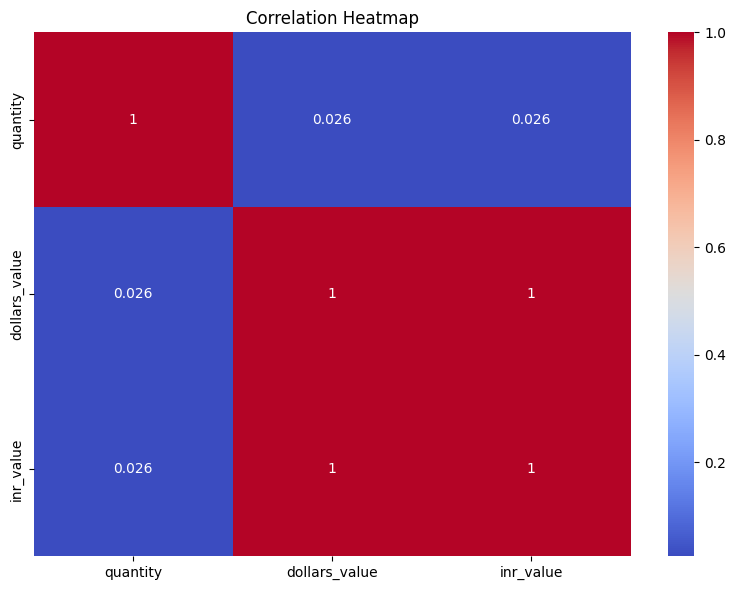

In [39]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['quantity',
        'dollars_value',
        'inr_value']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

***Insight:-*** There is a perfect postive correlation(1.0) between dollars_value and inr_value, which simply reflects the fixed currency exchange rate conversion. however, quantity shows an extremely weak correlation (0.026) with both value columns, providing that transaction volumes do not linearly dictate financial worth due to varying product prices.

### (viii)Top Countries Import Share

* ***Visualization Type:-*** Donut Chart
* ***Purpose:-*** show top country contribution.


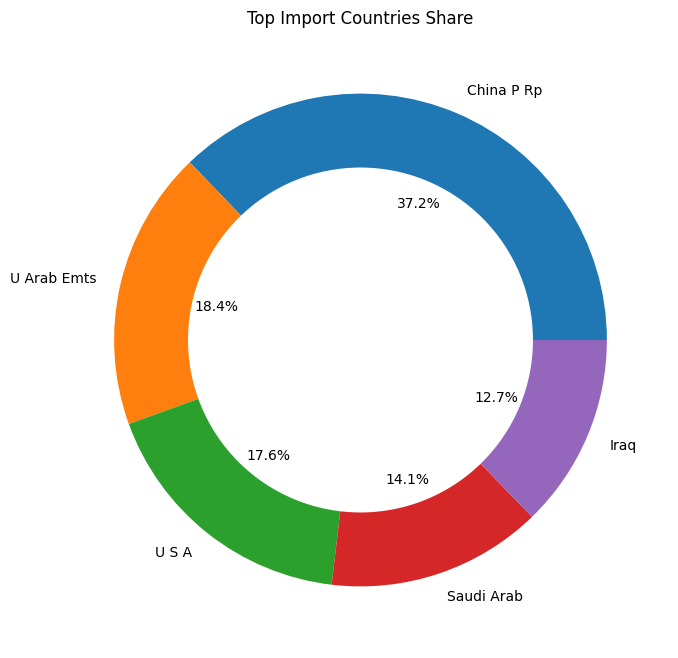

In [40]:
top_countries = df.groupby(
    'country'
)['inr_value'].sum().nlargest(5)

plt.figure(figsize=(8,8))

plt.pie(
    top_countries,
    labels=top_countries.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Top Import Countries Share')

plt.show()

***Insight:-*** China heavily dominates as the primary import partner, accounting for more thane one-third of the total share at 37.2%. The remaining market share is relatively evenly distributed among a secondary tier of major trade partners, led by the UAE (18.4%), The USA (17.6%),Saudi Arabia(14.12%), and Iraq(12.7%).

### (ix) Country vs Commodity Category

* ***Visualization Type:-*** Stacked bar Chart
* ***Puropse:-*** Compare country imports by category

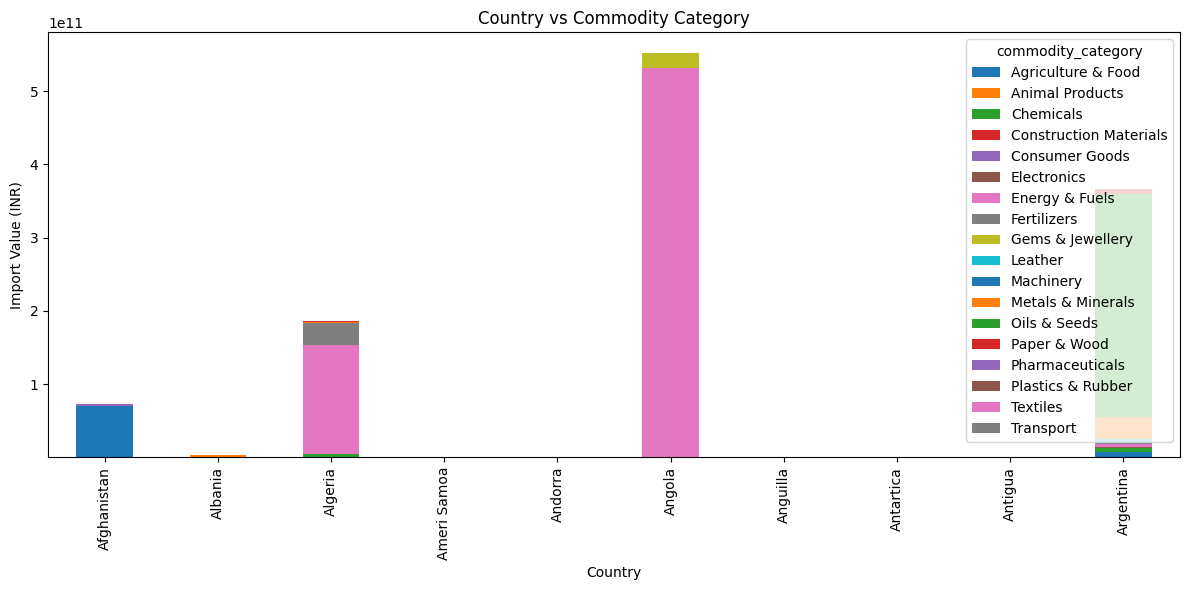

In [41]:
pivot = pd.pivot_table(
    df,
    values='inr_value',
    index='country',
    columns='commodity_category',
    aggfunc='sum'
).head(10)

pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Country vs Commodity Category')
plt.xlabel('Country')
plt.ylabel('Import Value (INR)')

plt.tight_layout()
plt.show()

***Insight:-*** Import distribution across these initial trading partners is heavily concentrated, with Angola and Algeria driving the highest financila volumes, dominated almost entirely by Energy & Fuels(represented by the tall purple blocks). in contrast, smaller trade values like Afghanistan rely on completely different sectors, specifically Agriculture & Food

### (X) Yearly Import Trend by Category

* ***Visualization Type:-*** Stacked Area Chart
* ***Purpose:-*** Analyze category contributions change across years.

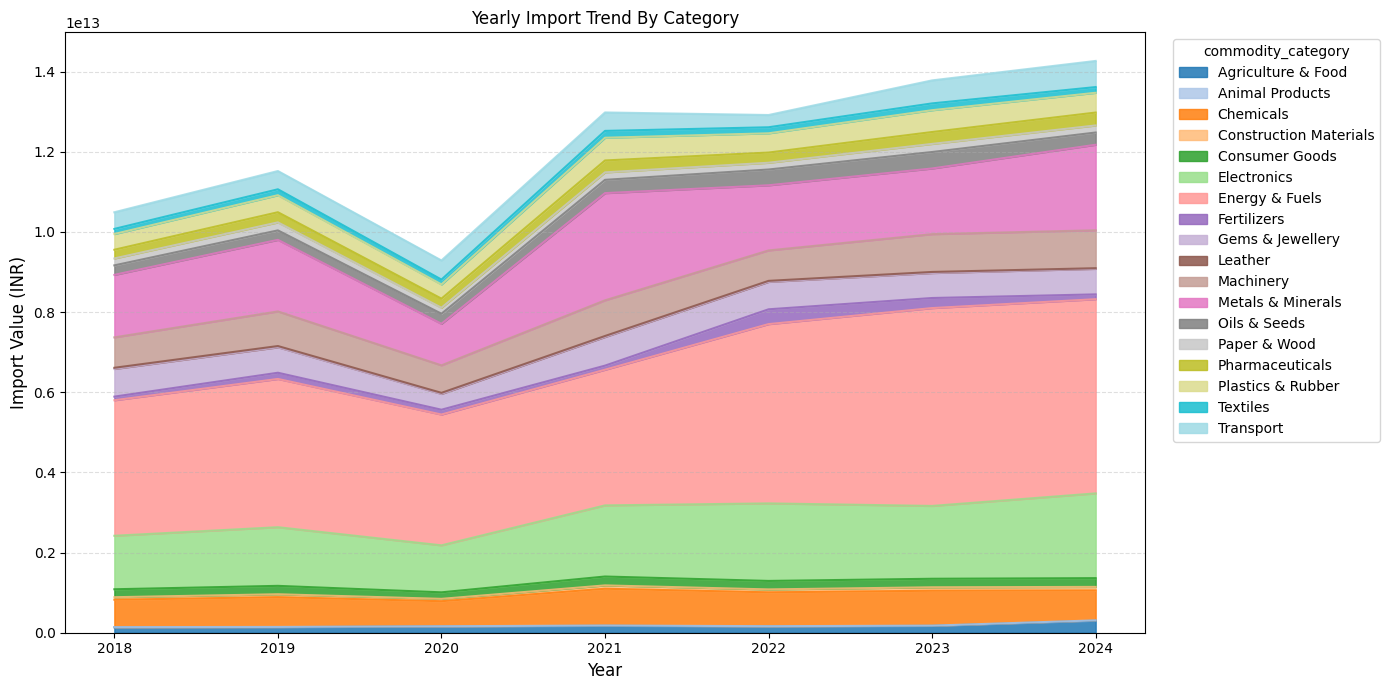

In [42]:
pivot_df = df.pivot_table(
    index='year',
    columns='commodity_category',
    values='inr_value',
    aggfunc='sum'
).fillna(0)
pivot_df.plot(kind='area',stacked=True,figsize=(14,7),colormap='tab20',alpha=0.85)
plt.title('Yearly Import Trend By Category')
plt.xlabel('Year',fontsize=12)
plt.ylabel('Import Value (INR)',fontsize=12)
plt.xticks(pivot_df.index)
plt.legend(title='commodity_category',bbox_to_anchor=(1.02,1),loc='upper left',fontsize=10)
plt.grid(axis='y',linestyle='--',alpha=0.4)
plt.tight_layout()
plt.show()


***Insight:-*** Total import experienced a sharp decline in 2020(likely due to golbal pandemic trade disruptions), followed by a strong recoverey that peaked high in 2024. Throughout this entire timeline, energy & fuels (the large pink layer) and Electronics(the prominent purple layer)consistently maintain the largest share of the volume, proving to be the primary structural drivers of import valuation changes over the years.

### (xi) Top 10 States by Import Value



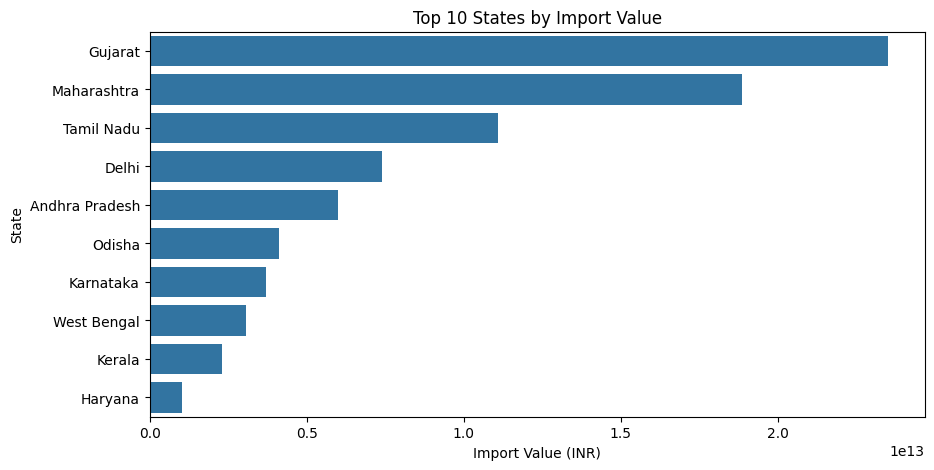

In [43]:
top_states = df.groupby('state_name')['inr_value'].sum().nlargest(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_states.values,y=top_states.index)

plt.title("Top 10 States by Import Value")
plt.xlabel("Import Value (INR)")
plt.ylabel("State")
plt.show()

***Insight:-*** Gujarat records the highest import value among all states, followed by Maharashtra and Tamil Nadu. This indicates that these states are major import hubs due to the presence of large ports, industrial zones, and strong trade infrasturcture. the chart also shows asiginificant gap between the top three states and the remaining states, highlighting the concentration of import activities in a few regions of india.

<h2 style="
    text-align:center;
    background-color:#eef3ff;
    padding:10px 15px;
    border-radius:5px;
    color:#2c7be5;
    font-size:30px
">
 Insight Generation and Report
</h2>

## Key Insights

1. The import value of India shows significant variation across different commodities.

2. Energy & Fuels, Oil & Seed, and Electronic products contribute a major share of total imports.

3. Certain countries consistently account for a large percentage of India's imports, indicating strong trade relationships.

4. Import values have shown noticeable fluctuations across different years, reflecting changes in market demand and economic conditions.

5. A positive relationship exists between quantity imported and total import value for several commodity groups.

6. Some commodity categories exhibit higher import concentrations than others, suggesting dependency on specific sectors.

7. Correlation analysis indicates a strong association between Dollar Value and INR Value, as both measure import worth in different currencies.

8. Several commodities contribute only a small portion of overall imports, while a few major commodities dominate the import market.

9. China is India's largest import partner and contributes a significant portion of total imports.


## Conclusion

The Indian Import Trend Analysis project provides valuable insights into import patterns, commodity demand, trade partnerships, and import value fluctuations. The analysis helps identify major import-driving commodities, key trading countries, and long-term trends. These findings can support business decision-making, market research, and policy planning related to international trade.

## Recommendations

- Focus on monitoring high-value import commodities.
- Strengthen trade relationships with major import partner countries.
- Track monthly and yearly import trends for forecasting future demand.
- Reduce dependency on highly imported commodities through domestic production where feasible.
- Use data-driven strategies for better import planning and resource allocation.